<a href="https://colab.research.google.com/github/Wessam2006/Phase2---Code-S25/blob/main/pnuemonia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
print(torch.cuda.is_available)

<function is_available at 0x7bd7ef3827a0>


In [ ]:
from google.colab import files
files.upload()


Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"wessamwaleed","key":"4a2cc0e00734931f6191c77c59858a51"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp "kaggle (1).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets list

ref                                                          title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
dmahajanbe23/bmw-global-automotive-sales                     BMW Global Automotive Sales                              55017  2026-02-22 18:18:38.170000           8842        172  1.0              
ssssws/chocolate-sales-dataset-2023-2024                     Chocolate Sales Dataset 2023 - 2024                   24420255  2026-03-07 04:58:02.387000           2451         52  1.0              
jayjoshi37/sleep-screen-time-and-stress-analysis             Sleep, Screen Time and Stress Analysis                  310158  2026-03-11 14:21:59.017000           1158         26  1.0              
shree0910/ai-an

In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 99% 2.27G/2.29G [00:23<00:00, 276MB/s]
100% 2.29G/2.29G [00:23<00:00, 106MB/s]


In [ ]:
!unzip chest-xray-pneumonia.zip


Streaming output truncated to the last 5000 lines.
  inflating: chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0447-0001.jpeg  
  inflating:

In [ ]:
import os
for root, dirs, files in os.walk("/content/chest_xray"):
    level = root.replace("/content/chest_xray", "").count(os.sep)
    if level < 3:
        print(root)

/content/chest_xray
/content/chest_xray/chest_xray
/content/chest_xray/chest_xray/val
/content/chest_xray/chest_xray/test
/content/chest_xray/chest_xray/train
/content/chest_xray/val
/content/chest_xray/val/PNEUMONIA
/content/chest_xray/val/NORMAL
/content/chest_xray/test
/content/chest_xray/test/PNEUMONIA
/content/chest_xray/test/NORMAL
/content/chest_xray/train
/content/chest_xray/train/PNEUMONIA
/content/chest_xray/train/NORMAL
/content/chest_xray/__MACOSX
/content/chest_xray/__MACOSX/chest_xray


In [ ]:
!pip install sympy==1.13.1 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 50.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.10.0+cu128 requires sympy>=1.13.3, but you have sympy 1.13.1 which is incompatible.


Using device: cuda
GPU: Tesla T4

Checking folder structure...
  train/ -> ['PNEUMONIA', 'NORMAL']
  val/ -> ['PNEUMONIA', 'NORMAL']
  test/ -> ['PNEUMONIA', 'NORMAL']

Detected classes: ['NORMAL', 'PNEUMONIA']
Train: 5216 images
Val:   16 images
Test:  624 images

Found saved model — loading best_model.pth

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.84      0.88      0.86       234
   PNEUMONIA       0.93      0.90      0.91       390

    accuracy                           0.89       624
   macro avg       0.89      0.89      0.89       624
weighted avg       0.90      0.89      0.89       624

ROC-AUC: 0.9553


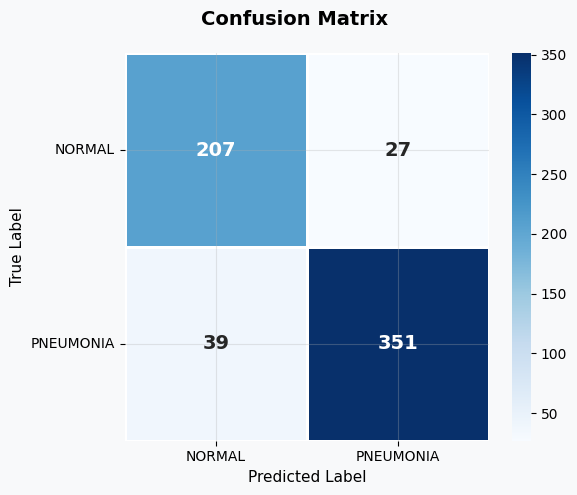

Saved: confusion_matrix.png


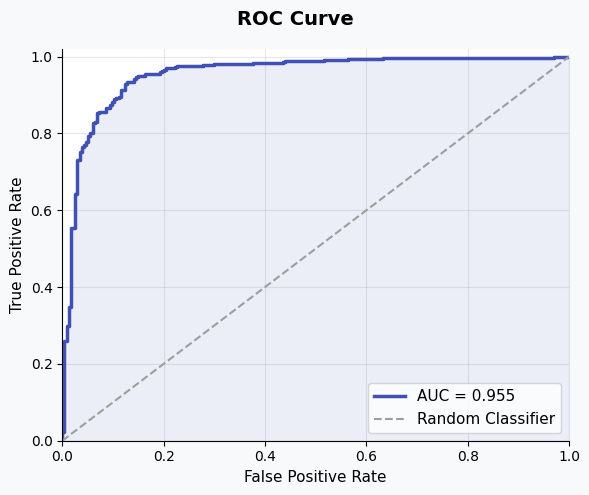

Saved: roc_curve.png


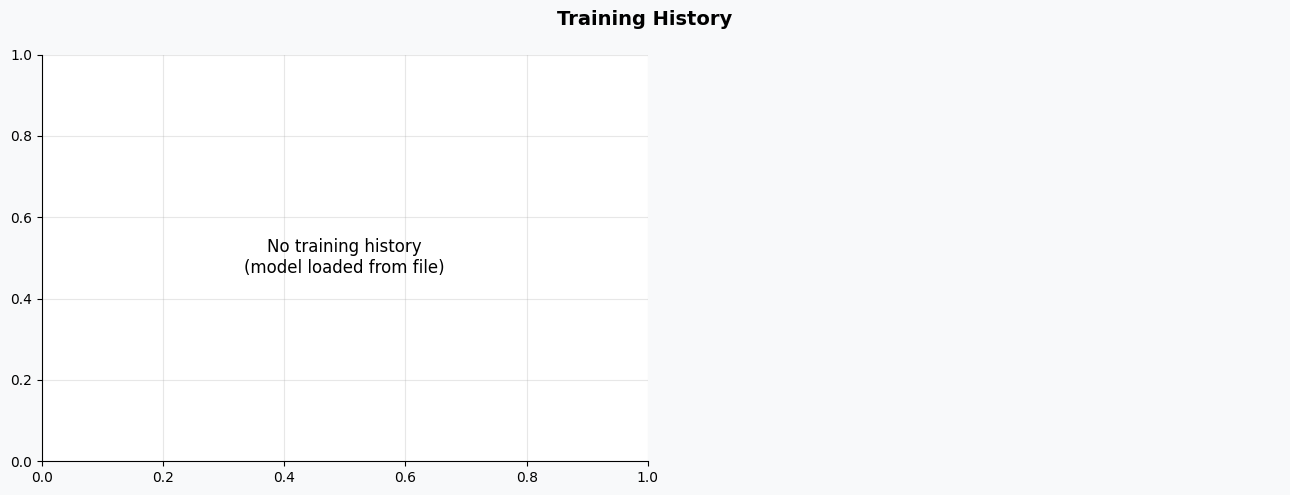

Saved: training_curves.png


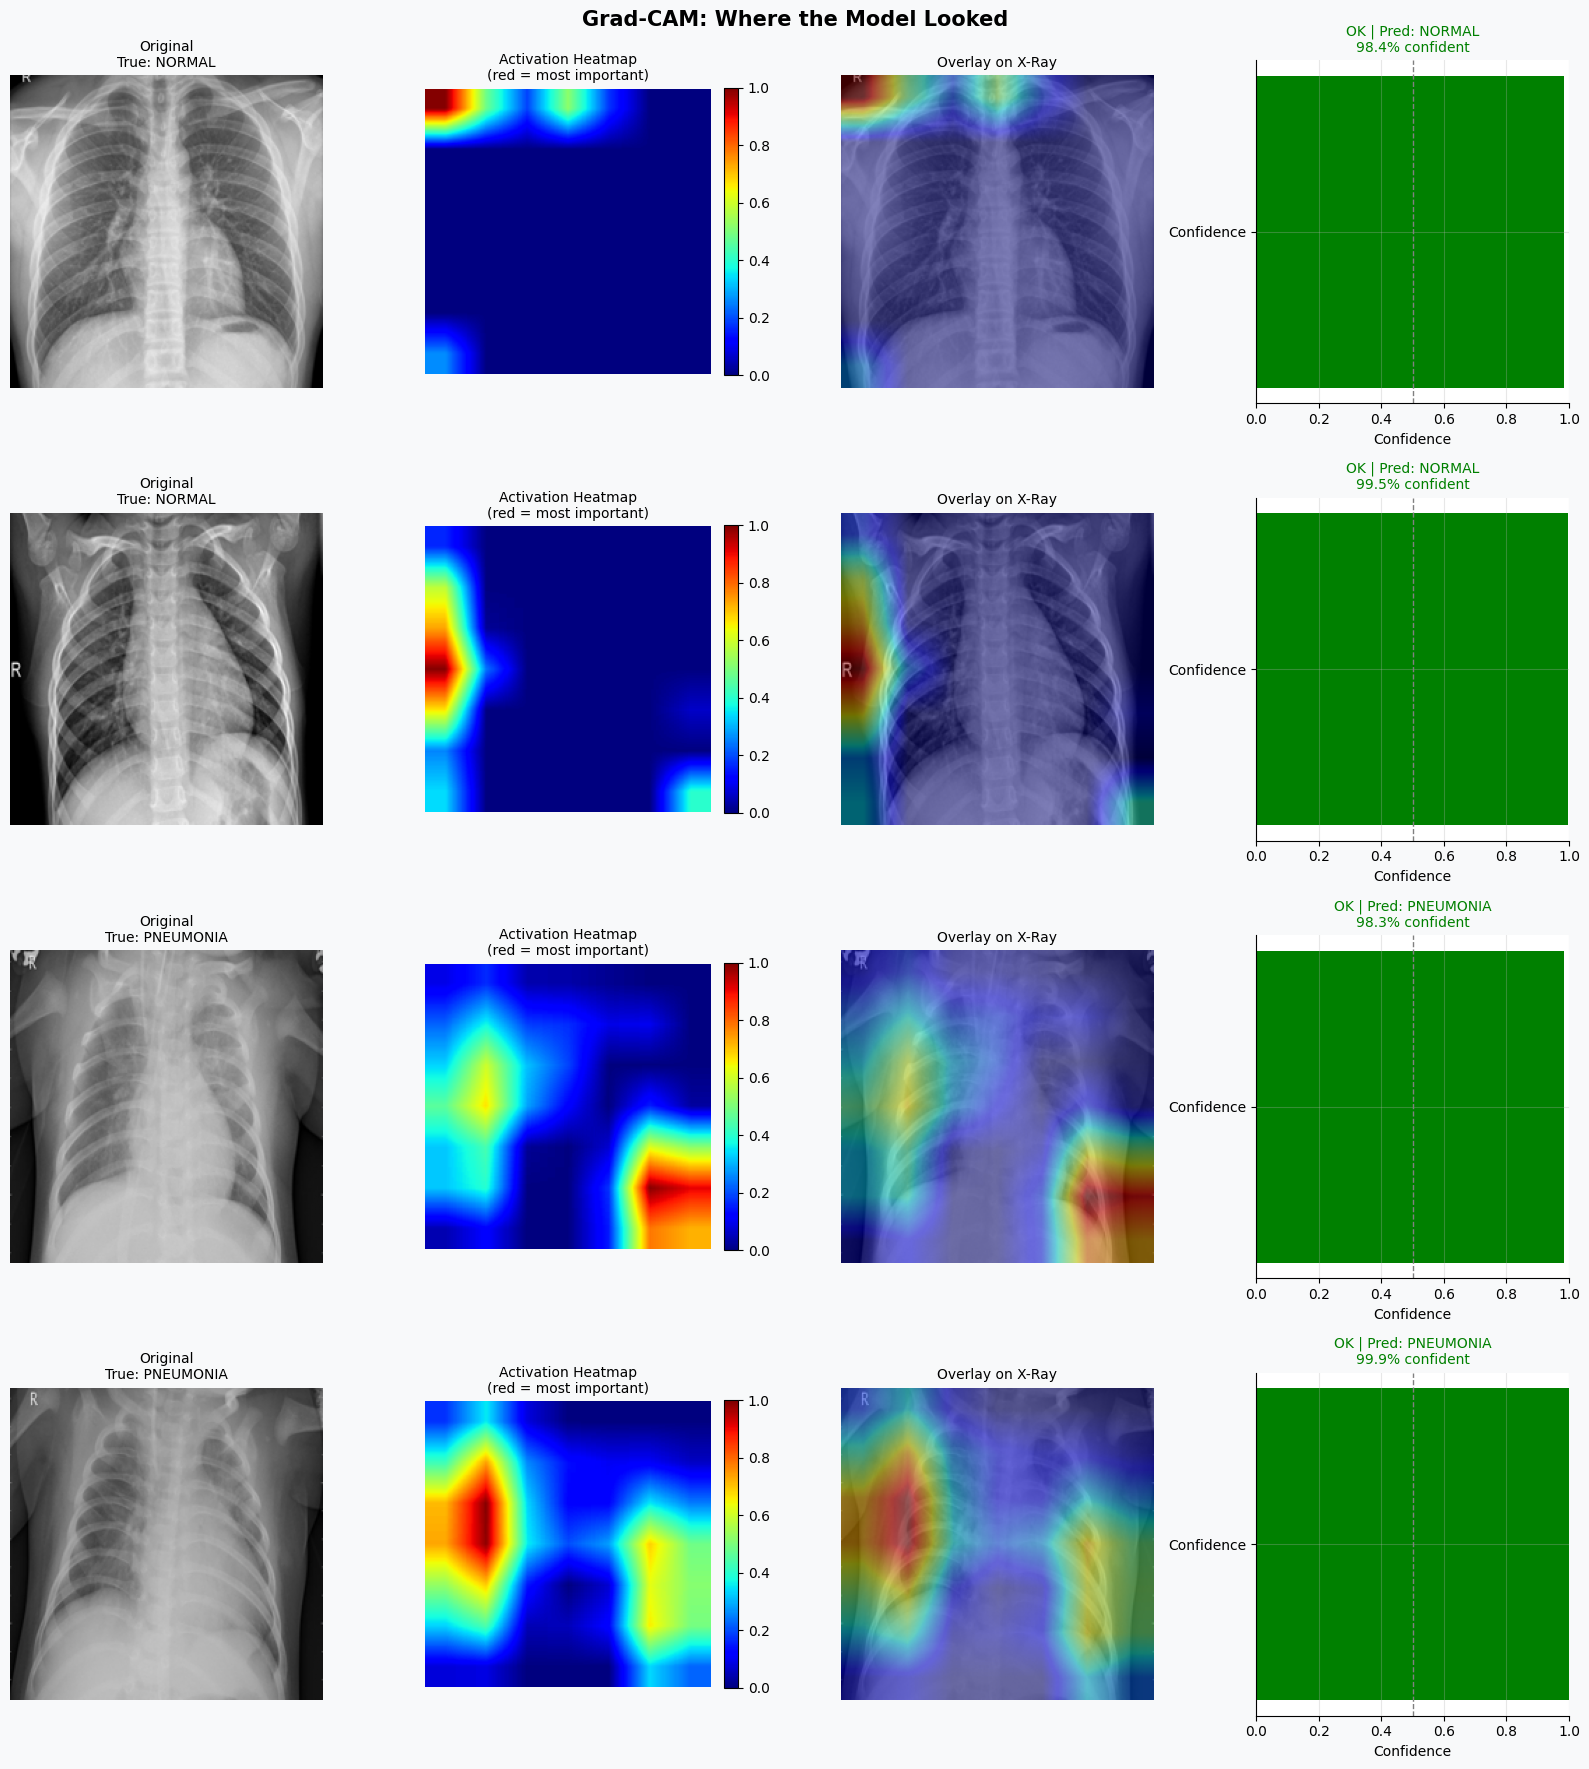

Saved: gradcam_output.png


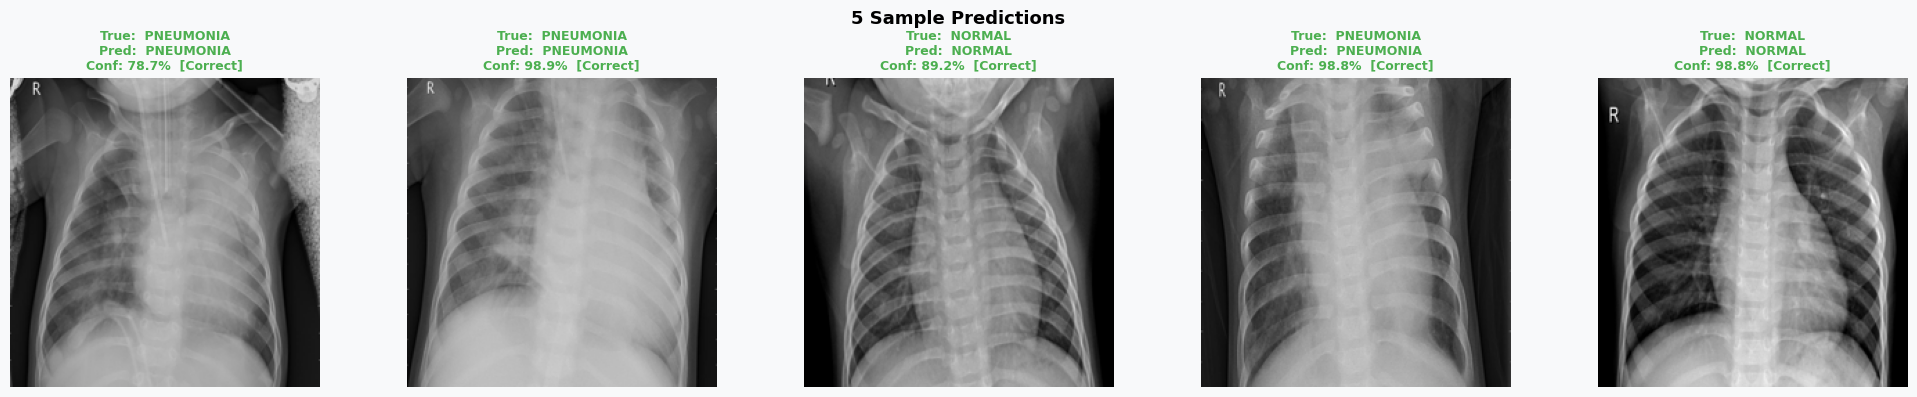

Saved: sample_predictions.png

All done! Outputs saved:
  confusion_matrix.png                [OK]
  roc_curve.png                       [OK]
  training_curves.png                 [OK]
  gradcam_output.png                  [OK]
  sample_predictions.png              [OK]
  best_model.pth                      [OK]

To download all files from Colab, run:
  from google.colab import files
  files.download('confusion_matrix.png')
  files.download('sample_predictions.png')
  files.download('best_model.pth')


In [ ]:
# =============================================================================
# Pneumonia Detection from Chest X-Ray — PyTorch Version (Colab + GPU Ready)
# =============================================================================

# =============================================================================
# STEP 0 — INSTALL & DOWNLOAD DATASET
# Run this cell first in Colab:
#
# !pip install kaggle -q
# from google.colab import files
# files.upload()  # upload your kaggle.json
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d pcbreviglieri/pneumonia-xray-images --unzip -p /content/chest_xray -q
# =============================================================================

# 👇 UPDATE THIS PATH if your folder is named differently
DATASET_PATH = "/content/chest_xray"

# =============================================================================
# IMPORTS
# =============================================================================
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from PIL import Image
from IPython.display import display   # Colab: display figures inline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models

from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

# =============================================================================
# SETTINGS
# =============================================================================
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 15
LR         = 1e-3
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

train_dir = os.path.join(DATASET_PATH, "train")
val_dir   = os.path.join(DATASET_PATH, "val")
test_dir  = os.path.join(DATASET_PATH, "test")

# Check folders exist
print("\nChecking folder structure...")
for split, path in [("train", train_dir), ("val", val_dir), ("test", test_dir)]:
    if os.path.exists(path):
        print(f"  {split}/ -> {os.listdir(path)}")
    else:
        print(f"  MISSING: {path}")

# =============================================================================
# STEP 1 — LOAD DATA
# =============================================================================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir,   transform=basic_transform)
test_dataset  = datasets.ImageFolder(test_dir,  transform=basic_transform)

# Auto-detect class names from folder names (handles any dataset naming)
CLASSES = list(train_dataset.class_to_idx.keys())
print(f"\nDetected classes: {CLASSES}")
print(f"Train: {len(train_dataset)} images")
print(f"Val:   {len(val_dataset)} images")
print(f"Test:  {len(test_dataset)} images")

# Handle class imbalance
labels      = [label for _, label in train_dataset.samples]
class_count = [labels.count(i) for i in range(len(CLASSES))]
weights     = [1.0 / class_count[label] for label in labels]
sampler     = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=2)

# =============================================================================
# STEP 2 — BUILD MODEL
# =============================================================================
model = models.resnet18(weights="IMAGENET1K_V1") #loads model alr trained on images,can detect edges textures..

for param in model.parameters(): #freezes pretrained layers,only new layers will learn
    param.requires_grad = False

model.fc = nn.Sequential( #classification head,originally outputs 1000 class
    nn.Linear(model.fc.in_features, 128), #takes features extracted and converts them to 128 neurons
    nn.ReLU(), #introduces nonlinearity to learn complex rs
    nn.Dropout(0.3),#30% features randomly turned off prevents overfitting
    nn.Linear(128, 1), #reduces into 1 feature
    nn.Sigmoid(), #converts number to probabilities
)

model = model.to(DEVICE) #cpu or gpu

criterion = nn.BCELoss() #measures how wrong predicition is
optimizer = optim.Adam(model.fc.parameters(), lr=LR) #updates weights to reduce loss
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
#changes learning rate during training

# =============================================================================
# STEP 3 — TRAIN
# =============================================================================
MODEL_PATH = "best_model.pth"

def run_epoch(loader, is_train):
    model.train() if is_train else model.eval()
    total_loss, correct = 0, 0

    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.float().to(DEVICE)
            outputs = model(images).squeeze()
            loss    = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * len(images)
            correct    += ((outputs >= 0.5).int() == labels.int()).sum().item()

    return total_loss / len(loader.dataset), correct / len(loader.dataset)


train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

if os.path.exists(MODEL_PATH):
    print("\nFound saved model — loading best_model.pth")
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))

else:
    best_val_acc     = 0
    patience_counter = 0

    print("\nTraining (Phase 1 — frozen backbone)...")
    for epoch in range(EPOCHS):
        train_loss, train_acc = run_epoch(train_loader, is_train=True)
        val_loss,   val_acc   = run_epoch(val_loader,   is_train=False)
        scheduler.step(val_loss)

        train_losses.append(train_loss); train_accs.append(train_acc)
        val_losses.append(val_loss);     val_accs.append(val_acc)

        print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), MODEL_PATH)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 5:
                print("Early stopping.")
                break

    print("\nTraining (Phase 2 — fine-tuning all layers)...")
    for param in model.parameters():
        param.requires_grad = True
    optimizer = optim.Adam(model.parameters(), lr=1e-5)

    for epoch in range(5):
        train_loss, train_acc = run_epoch(train_loader, is_train=True)
        val_loss,   val_acc   = run_epoch(val_loader,   is_train=False)

        train_losses.append(train_loss); train_accs.append(train_acc)
        val_losses.append(val_loss);     val_accs.append(val_acc)

        print(f"Fine-tune Epoch {epoch+1}/5 | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), MODEL_PATH)

    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
    print(f"\nBest val accuracy: {best_val_acc:.4f}")

# =============================================================================
# STEP 4 — EVALUATE
# =============================================================================
model.eval()
all_probs, all_preds, all_labels = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        probs  = model(images).squeeze().cpu().numpy()
        preds  = (probs >= 0.5).astype(int)
        # Handle single-image batch (squeeze removes batch dim)
        all_probs.extend(probs.flatten().tolist())
        all_preds.extend(preds.flatten().tolist())
        all_labels.extend(labels.numpy().tolist())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_prob = np.array(all_probs)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASSES))
print(f"ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")

# =============================================================================
# VISUAL STYLE
# =============================================================================
plt.rcParams.update({
    "figure.facecolor": "#f8f9fa",
    "axes.facecolor":   "#ffffff",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.family":      "DejaVu Sans",
    "axes.spines.top":  False,
    "axes.spines.right":False,
})
PALETTE = {"normal": "#2196F3", "pneumonia": "#F44336", "line": "#3F51B5", "ref": "#9E9E9E"}

def show_and_save(fig, filename):
    """Save figure and display inline in Colab."""
    fig.savefig(filename, dpi=150, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    print(f"Saved: {filename}")

# --- Figure 1: Confusion Matrix ---
fig1, ax = plt.subplots(figsize=(6, 5))
fig1.suptitle("Confusion Matrix", fontsize=14, fontweight="bold")
cm_data = confusion_matrix(y_true, y_pred)
sns.heatmap(cm_data, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=1, linecolor="white",
            annot_kws={"size": 14, "weight": "bold"}, ax=ax)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
ax.set_xticklabels(CLASSES, fontsize=10)
ax.set_yticklabels(CLASSES, fontsize=10, rotation=0)
fig1.tight_layout()
show_and_save(fig1, "confusion_matrix.png")

# --- Figure 2: ROC Curve ---
fpr, tpr, _ = roc_curve(y_true, y_prob)
auc_score   = roc_auc_score(y_true, y_prob)
fig2, ax    = plt.subplots(figsize=(6, 5))
fig2.suptitle("ROC Curve", fontsize=14, fontweight="bold")
ax.plot(fpr, tpr, color=PALETTE["line"], lw=2.5, label=f"AUC = {auc_score:.3f}")
ax.fill_between(fpr, tpr, alpha=0.1, color=PALETTE["line"])
ax.plot([0, 1], [0, 1], "--", color=PALETTE["ref"], lw=1.5, label="Random Classifier")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.legend(fontsize=11)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
fig2.tight_layout()
show_and_save(fig2, "roc_curve.png")

# --- Figure 3: Training Curves ---
fig3, axes3 = plt.subplots(1, 2, figsize=(13, 5))
fig3.suptitle("Training History", fontsize=14, fontweight="bold")

if train_accs:
    epochs_range = range(1, len(train_accs) + 1)
    axes3[0].plot(epochs_range, train_accs, color=PALETTE["normal"],    lw=2, label="Train")
    axes3[0].plot(epochs_range, val_accs,   color=PALETTE["pneumonia"], lw=2, label="Validation", linestyle="--")
    axes3[0].set_title("Accuracy"); axes3[0].set_xlabel("Epoch"); axes3[0].legend()

    axes3[1].plot(epochs_range, train_losses, color=PALETTE["normal"],    lw=2, label="Train")
    axes3[1].plot(epochs_range, val_losses,   color=PALETTE["pneumonia"], lw=2, label="Validation", linestyle="--")
    axes3[1].set_title("Loss"); axes3[1].set_xlabel("Epoch"); axes3[1].legend()
else:
    axes3[0].text(0.5, 0.5, "No training history\n(model loaded from file)",
                  ha="center", va="center", fontsize=12, transform=axes3[0].transAxes)
    axes3[1].axis("off")

fig3.tight_layout()
show_and_save(fig3, "training_curves.png")

# =============================================================================
# STEP 5 — GRAD-CAM EXPLAINABILITY
# =============================================================================
activations, gradients = {}, {}

def forward_hook(module, input, output):
    activations["value"] = output

def backward_hook(module, grad_input, grad_output):
    gradients["value"] = grad_output[0]

target_layer = model.layer4[1].conv2
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)
# Warm-up pass to populate hooks
_ = model(torch.zeros(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE))


def get_gradcam(img_tensor):
    model.eval()
    img_tensor = img_tensor.unsqueeze(0).to(DEVICE)
    img_tensor.requires_grad_(True)
    output = model(img_tensor).squeeze()
    model.zero_grad()
    output.backward(retain_graph=True)

    grads   = gradients["value"].squeeze().cpu().detach().numpy()
    acts    = activations["value"].squeeze().cpu().detach().numpy()
    weights = grads.mean(axis=(1, 2))

    heatmap = np.zeros(acts.shape[1:])
    for i, w in enumerate(weights):
        heatmap += w * acts[i]

    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (heatmap.max() + 1e-8)
    return heatmap


def get_gradcam_overlay(img_path):
    raw_img    = Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    raw_arr    = np.array(raw_img) / 255.0
    img_tensor = basic_transform(raw_img)
    prob       = float(model(img_tensor.unsqueeze(0).to(DEVICE)).squeeze().item())
    pred_cls   = CLASSES[int(prob >= 0.5)]
    conf       = prob if prob >= 0.5 else 1 - prob
    heatmap    = get_gradcam(img_tensor)

    heatmap_pil    = Image.fromarray(np.uint8(255 * heatmap)).resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    heatmap_smooth = np.array(heatmap_pil) / 255.0
    heat_colored   = cm.jet(np.uint8(255 * heatmap_smooth))[:, :, :3]
    overlay        = np.clip(heat_colored * 0.45 + raw_arr * 0.55, 0, 1)

    return raw_arr, heatmap_smooth, overlay, pred_cls, conf


# Pick 2 images per class
sample_imgs = []
for cls in CLASSES:
    cls_folder = os.path.join(test_dir, cls)
    cls_files  = [os.path.join(cls_folder, f) for f in os.listdir(cls_folder)
                  if f.lower().endswith((".jpeg", ".jpg", ".png"))]
    sample_imgs += [(f, cls) for f in random.sample(cls_files, min(2, len(cls_files)))]

fig4, axes4 = plt.subplots(len(sample_imgs), 4, figsize=(16, 4.5 * len(sample_imgs)))
fig4.suptitle("Grad-CAM: Where the Model Looked", fontsize=15, fontweight="bold")

for i, (img_path, true_cls) in enumerate(sample_imgs):
    raw_arr, heatmap, overlay, pred_cls, conf = get_gradcam_overlay(img_path)
    correct = "OK" if pred_cls == true_cls else "WRONG"
    color   = "green" if pred_cls == true_cls else "red"

    axes4[i][0].imshow(raw_arr, cmap="gray")
    axes4[i][0].set_title(f"Original\nTrue: {true_cls}", fontsize=10)
    axes4[i][0].axis("off")

    im = axes4[i][1].imshow(heatmap, cmap="jet", vmin=0, vmax=1)
    axes4[i][1].set_title("Activation Heatmap\n(red = most important)", fontsize=10)
    axes4[i][1].axis("off")
    plt.colorbar(im, ax=axes4[i][1], fraction=0.046, pad=0.04)

    axes4[i][2].imshow(overlay)
    axes4[i][2].set_title("Overlay on X-Ray", fontsize=10)
    axes4[i][2].axis("off")

    axes4[i][3].barh(["Confidence"], [conf], color=color, height=0.4)
    axes4[i][3].set_xlim(0, 1)
    axes4[i][3].set_title(f"{correct} | Pred: {pred_cls}\n{conf:.1%} confident", fontsize=10, color=color)
    axes4[i][3].set_xlabel("Confidence")
    axes4[i][3].axvline(0.5, color="gray", linestyle="--", linewidth=1)

fig4.tight_layout()
show_and_save(fig4, "gradcam_output.png")

# =============================================================================
# STEP 6 — 5 SAMPLE PREDICTIONS (static grid — Colab compatible)
# =============================================================================
all_imgs = []
for cls in CLASSES:
    cls_folder = os.path.join(test_dir, cls)
    cls_files  = [os.path.join(cls_folder, f) for f in os.listdir(cls_folder)
                  if f.lower().endswith((".jpeg", ".jpg", ".png"))]
    all_imgs += [(f, cls) for f in random.sample(cls_files, min(3, len(cls_files)))]

sample5 = random.sample(all_imgs, min(5, len(all_imgs)))

pred_data = []
for img_path, true_cls in sample5:
    raw_img    = Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    img_tensor = basic_transform(raw_img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        prob = float(model(img_tensor).squeeze().item())
    pred = CLASSES[int(prob >= 0.5)]
    conf = prob if prob >= 0.5 else 1 - prob
    pred_data.append((np.array(raw_img), true_cls, pred, conf))

# Static grid (interactive buttons don't work in Colab)
fig5, axes_s = plt.subplots(1, len(pred_data), figsize=(4 * len(pred_data), 4))
fig5.suptitle("5 Sample Predictions", fontsize=13, fontweight="bold")

for ax, (img_arr, true_cls, pred, conf) in zip(axes_s, pred_data):
    color  = "#4CAF50" if pred == true_cls else "#F44336"
    status = "Correct" if pred == true_cls else "Wrong"
    ax.imshow(img_arr, cmap="gray")
    ax.set_title(
        f"True:  {true_cls}\nPred:  {pred}\nConf: {conf:.1%}  [{status}]",
        color=color, fontsize=9, fontweight="bold"
    )
    ax.axis("off")

fig5.tight_layout()
show_and_save(fig5, "sample_predictions.png")

# =============================================================================
# DONE — download outputs from Colab
# =============================================================================
print("\nAll done! Outputs saved:")
for f in ["confusion_matrix.png", "roc_curve.png", "training_curves.png",
          "gradcam_output.png", "sample_predictions.png", "best_model.pth"]:
    exists = "OK" if os.path.exists(f) else "MISSING"
    print(f"  {f:35s} [{exists}]")

print("\nTo download all files from Colab, run:")
print("  from google.colab import files")
print("  files.download('confusion_matrix.png')")
print("  files.download('sample_predictions.png')")
print("  files.download('best_model.pth')")